# EDA — Brain Tumor MRI Dataset

Proyecto final — Tecnicatura en Ciencias de Datos. Bimestre 1 (local).

**Objetivo.** Entender el dataset antes de tocar una sola línea de modelado, y salir de
acá con evidencia para tres decisiones que hoy están en `TBD`:

| Pregunta del EDA | Decisión que destraba |
|---|---|
| ¿Está balanceado por clase? | Si hace falta pesar la loss o balancear el sampling |
| ¿Qué resoluciones tienen las imágenes? | El valor de `data.image_size` en `config/config.yaml` (hoy 150 sin justificar) |
| ¿Cuánto fondo negro y qué contraste tienen? | Hasta dónde puede llegar el augmentation sin distorsionar features clínicas |
| ¿Hay imágenes duplicadas? | Si hay riesgo de fuga de datos entre train y test |

**Nota sobre el framework.** Este notebook no importa PyTorch ni TensorFlow a propósito:
esa decisión sigue abierta, y el EDA es justamente la parte del proyecto que no depende
de ella.

---
## 0. Setup

> **Kernel local.** Este notebook corre con el intérprete del venv del proyecto
> (`.venv/`), no en una VM remota. El código de `src/` se ve directo desde disco:
> no hace falta pushear a GitHub para que un cambio se refleje acá.

In [2]:
# Raíz del proyecto: la carpeta que contiene notebooks/. La usa la celda de
# abajo para el sys.path, así `from src.data import eda` resuelve siempre,
# sin importar desde qué directorio se lanzó Jupyter.
from pathlib import Path

REPO_DIR = str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
print("Raíz del proyecto:", REPO_DIR)

Raíz del proyecto: c:\Users\Win10\OneDrive\Desktop\Franco\Estudio\Ciencias de datos\Proyecto Final\mri-tumor-classifier\mri-tumor-classifier


In [3]:
%load_ext autoreload
%autoreload 2
# Recarga automática de src/ en cada celda: al tocar eda.py (u otro módulo de
# src/) no hace falta reiniciar el kernel para que el notebook vea el cambio.

import sys

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

import matplotlib.pyplot as plt
import pandas as pd

from src.data import eda

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

print("Helpers disponibles:", [n for n in dir(eda) if not n.startswith("_")])

Helpers disponibles: ['CLASES', 'ETIQUETAS', 'EXTENSIONES', 'Image', 'Path', 'detectar_duplicados', 'estadisticas_intensidad', 'graficar_distribucion_clases', 'graficar_intensidades', 'graficar_muestras', 'graficar_resoluciones', 'hashlib', 'inspeccionar_metadatos', 'listar_imagenes', 'np', 'pd', 'plt', 'recomendar_image_size', 'resumen_por_clase']


### 0.1 Credenciales de Kaggle

El dataset se baja con la API de Kaggle, que necesita un token. Local lo tomamos del
`.env` en la raíz del proyecto (`KAGGLE_API_TOKEN`), que **no se commitea**
(está en `.gitignore`). Si todavía no lo completaste:

1. Entrá a <https://www.kaggle.com/settings> → sección **API** → *Create New Token*.
2. Pegá el token en `KAGGLE_API_TOKEN` en el archivo `.env` de la raíz del proyecto.

In [4]:
from dotenv import load_dotenv

# Carga KAGGLE_API_TOKEN del .env como variable de entorno.
# kagglehub lo busca ahí automáticamente, sin pedir login interactivo.
load_dotenv(Path(REPO_DIR) / ".env")

import kagglehub

try:
    kagglehub.whoami()
    print("Ya estás autenticado en Kaggle.")
except Exception as e:
    raise RuntimeError(
        "No se pudo autenticar con Kaggle. Revisá que KAGGLE_API_TOKEN "
        "esté completo en el .env de la raíz del proyecto."
    ) from e

Kaggle credentials successfully validated.
Ya estás autenticado en Kaggle.


In [5]:
# Descarga (y cachea) el dataset localmente. ~150 MB, tarda menos de un minuto
# la primera vez; después kagglehub reusa el cache.
ruta_dataset = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Dataset en:", ruta_dataset)

# Veamos cómo quedó organizado en disco.
import os

for raiz, dirs, archivos in os.walk(ruta_dataset):
    nivel = raiz.replace(str(ruta_dataset), "").count(os.sep)
    if nivel <= 2:
        print("  " * nivel + os.path.basename(raiz) + f"/  ({len(archivos)} archivos)")

Dataset en: C:\Users\Win10\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2
2/  (0 archivos)
  Testing/  (0 archivos)
    glioma/  (400 archivos)
    meningioma/  (400 archivos)
    notumor/  (400 archivos)
    pituitary/  (400 archivos)
  Training/  (0 archivos)
    glioma/  (1400 archivos)
    meningioma/  (1400 archivos)
    notumor/  (1400 archivos)
    pituitary/  (1400 archivos)


---
## 1. Inventario: qué hay realmente en el dataset

`eda.listar_imagenes()` recorre el árbol de carpetas y arma un DataFrame con una fila por
imagen. La clase sale del nombre de la carpeta contenedora, y `split_origen` guarda si la
imagen venía en `Training/` o en `Testing/` del dataset original.

Ojo con ese `split_origen`: es el split **que trae Kaggle**, no el nuestro. Nosotros vamos
a rehacer la división de forma estratificada y con semilla fija en
`preprocessing.split_dataset()`, así que por ahora es sólo información de contexto.

In [6]:
df = eda.listar_imagenes(ruta_dataset)

print(f"Total de imágenes encontradas: {len(df):,}")
print(f"Clases: {sorted(df['clase'].unique())}")
print(f"Carpetas de origen: {sorted(df['split_origen'].dropna().unique())}")
df.head()

Total de imágenes encontradas: 7,200
Clases: ['glioma', 'meningioma', 'notumor', 'pituitary']
Carpetas de origen: ['testing', 'training']


,path,archivo,clase,split_origen,peso_kb
0,C:\Users\Win10\.cache\kagglehub\datasets\masou...,Te-gl_1.jpg,glioma,testing,29.6
1,C:\Users\Win10\.cache\kagglehub\datasets\masou...,Te-gl_10.jpg,glioma,testing,16.1
2,C:\Users\Win10\.cache\kagglehub\datasets\masou...,Te-gl_100.jpg,glioma,testing,16.9
3,C:\Users\Win10\.cache\kagglehub\datasets\masou...,Te-gl_101.jpg,glioma,testing,24.8
4,C:\Users\Win10\.cache\kagglehub\datasets\masou...,Te-gl_102.jpg,glioma,testing,24.5


**Chequeo:** el dataset publicado dice tener 7.023 imágenes. Si el número de arriba no
coincide, hay algo que revisar antes de seguir (archivos extra, carpetas inesperadas o
imágenes fuera de las 4 clases).

---
## 2. Distribución por clase

La pregunta concreta: ¿hay una clase tan sub-representada que el modelo la vaya a ignorar?

Importa más de lo habitual acá. La métrica prioritaria del proyecto es **recall**, no
accuracy: un modelo que nunca predice la clase minoritaria puede tener accuracy alta y
recall desastroso justo en la clase que menos queremos fallar.

In [7]:
resumen = eda.resumen_por_clase(df)
resumen

,imagenes,porcentaje,peso_kb_medio
Glioma,1800,25.0,19.7
Meningioma,1800,25.0,21.9
Pituitario,1800,25.0,29.9
Sin tumor,1800,25.0,19.6


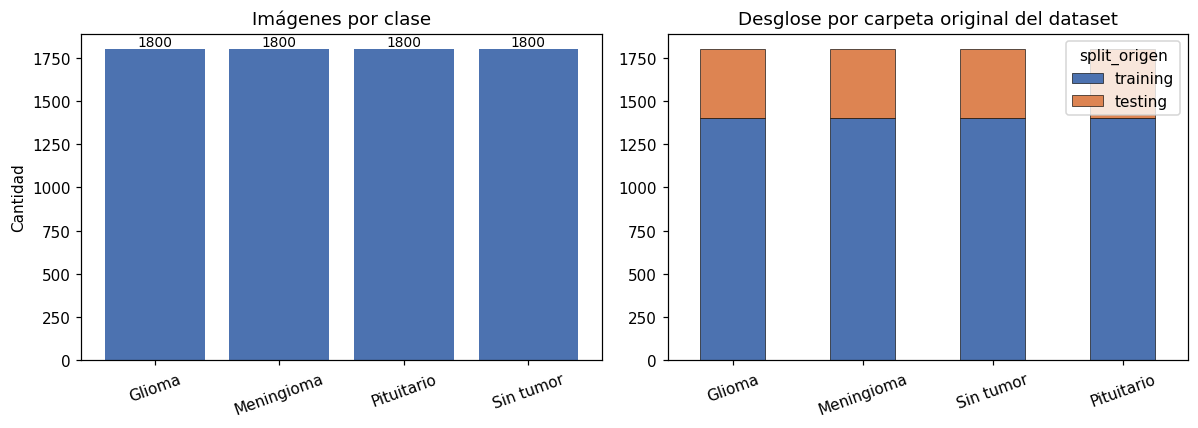

In [8]:
fig = eda.graficar_distribucion_clases(df)
plt.show()

**Conclusión (completar al correrlo):**

- Clase más frecuente: …
- Clase menos frecuente: …
- Ratio max/min: …
- ¿Hace falta balancear? …

---
## 3. Resoluciones — el insumo para `image_size`

Acá resolvemos el TBD más concreto del `config.yaml`. Hoy dice `image_size: 150` y ese
valor no salió de ningún lado.

Lo que importa no es el tamaño promedio, sino **cuántas imágenes habría que agrandar**
para llegar al tamaño elegido. Hacer upscaling de una MRI inventa detalle que no existe
en el estudio original, y en un contexto clínico eso es exactamente lo que no querés.

In [31]:
# Rápido incluso sobre 7.023 imágenes: PIL lee el header sin decodificar los píxeles.
df_meta = eda.inspeccionar_metadatos(df)

print("Imágenes que no se pudieron abrir:", (df_meta["modo"] == "ERROR").sum())
print("\nModos de color presentes:")
print(df_meta["modo"].value_counts())
print("\nResoluciones más frecuentes:")
print(df_meta.groupby(["ancho", "alto"]).size().sort_values(ascending=False).head(10))

df_meta[["ancho", "alto", "lado_menor", "aspect_ratio"]].describe().round(2)

Imágenes que no se pudieron abrir: 0

Modos de color presentes:
modo
RGB     4129
L       3067
RGBA       3
P          1
Name: count, dtype: int64

Resoluciones más frecuentes:
ancho  alto
512    512     5014
225    225      338
630    630       90
201    251       57
228    221       51
232    217       50
236    236       48
442    442       48
150    198       44
200    252       43
dtype: int64


,ancho,alto,lado_menor,aspect_ratio
count,7200.00,7200.0,7200.00,7200.00
mean,453.30,456.9,450.27,0.99
std,130.05,124.4,129.82,0.09
min,150.00,167.0,150.00,0.64
25%,442.00,449.0,442.00,1.00
50%,512.00,512.0,512.00,1.00
75%,512.00,512.0,512.00,1.00
max,1375.00,1446.0,1375.00,1.79


In [ ]:
fig = eda.graficar_resoluciones(df_meta)
plt.show()

In [ ]:
# Para cada candidato: qué porcentaje del dataset habría que agrandar vs achicar.
eda.recomendar_image_size(df_meta, candidatos=(150, 224, 256))

**Conclusión (completar al correrlo):**

- Resolución dominante: …
- ¿Son todas cuadradas? …
- ¿Vienen en escala de grises (`L`) o en RGB? Importa porque los backbones preentrenados
  (EfficientNet/MobileNet) esperan 3 canales: …
- **Valor elegido para `image_size`: …** — justificación: …

Cuando esto tenga número, hay que actualizarlo en tres lugares que hoy dicen TBD en
paralelo: `config/config.yaml`, `docs/model_card.md` y la sección de stack del `README.md`.

---
## 4. Muestras visuales

Mirar las imágenes no es decoración. Es lo que deja ver la orientación de los cortes
(axial, coronal, sagital), el contraste, cuánto fondo negro hay alrededor del cerebro y
si hay artefactos o texto quemado en la imagen.

Todo eso condiciona el augmentation: si los cortes vienen siempre en la misma orientación,
una rotación grande genera imágenes que no existen en la práctica clínica.

In [ ]:
fig = eda.graficar_muestras(df, n_por_clase=4)
plt.show()

**Observaciones (completar al correrlo):**

- Orientación de los cortes: …
- ¿Hay texto/anotaciones quemadas en la imagen? …
- ¿Se ve a simple vista la diferencia entre clases? …
- Implicancia para el augmentation: …

---
## 5. Calidad de imagen: intensidad, contraste y fondo

Estas estadísticas sí decodifican los píxeles, así que corren sobre una submuestra
estratificada por clase en vez de sobre las 7.023 imágenes.

Lo que buscamos: si alguna clase tiene un perfil de intensidad sistemáticamente distinto.
Si lo tuviera, el modelo podría estar aprendiendo el brillo de la máquina de resonancia en
vez de la patología — un atajo clásico en datasets médicos combinados de varias fuentes.

In [ ]:
df_stats = eda.estadisticas_intensidad(df, muestra=400, seed=42)

print(f"Analizadas {len(df_stats)} imágenes")
df_stats.groupby("clase")[["media", "desvio", "frac_fondo", "frac_saturada"]].mean().round(3)

In [ ]:
fig = eda.graficar_intensidades(df_stats)
plt.show()

**Conclusión (completar al correrlo):**

- ¿Los perfiles de intensidad se superponen entre clases, o alguna se separa? …
- Fracción de fondo negro típica: … → margen disponible para zoom/crop en el augmentation.
- ¿Hace falta normalizar por imagen, o alcanza con la normalización estándar del backbone? …

---
## 6. Duplicados

Este dataset es una combinación de tres fuentes (figshare + SARTAJ + Br35H), así que puede
traer la misma imagen más de una vez.

El riesgo concreto: si una imagen está duplicada y una copia cae en train mientras la otra
cae en test, las métricas de test van a estar infladas. El modelo aprueba el examen
habiendo visto las respuestas.

In [ ]:
duplicados = eda.detectar_duplicados(df)

print(f"Archivos que participan de algún grupo duplicado: {len(duplicados)}")
if len(duplicados):
    print(f"Grupos distintos: {duplicados['hash'].nunique()}")
    # ¿Hay duplicados que cruzan la frontera Training/Testing original?
    cruzados = duplicados.groupby("hash")["split_origen"].nunique()
    print(f"Grupos que cruzan Training/Testing: {(cruzados > 1).sum()}")
    display(duplicados.head(10)[["archivo", "clase", "split_origen", "hash"]])
else:
    print("No hay duplicados exactos.")

**Conclusión (completar al correrlo):**

- Duplicados exactos encontrados: …
- ¿Alguno cruza clases distintas? (sería una inconsistencia de etiquetado): …
- Decisión: …

> Nota: esto detecta duplicados **byte a byte**. No detecta la misma imagen guardada con
> otra compresión o recortada distinto. Si el número de arriba da sospechosamente bajo para
> un dataset combinado, vale la pena volver con un hash perceptual más adelante.

---
## 7. Conclusiones del EDA

**Resumen para el tutor (completar al correrlo):**

1. **Volumen y balance:** …
2. **Resolución elegida y por qué:** …
3. **Calidad de las imágenes:** …
4. **Duplicados / fuga de datos:** …
5. **Implicancias para el augmentation:** …

**Qué se destraba con esto:**

- [ ] Fijar `data.image_size` en `config/config.yaml` con justificación
- [ ] Definir si el entrenamiento necesita class weights
- [ ] Acotar los rangos del augmentation en `src/data/augmentation.py`
- [ ] Confirmar si hay que deduplicar antes del split estratificado

**Sigue sin resolverse acá** (y no depende del EDA): PyTorch vs TensorFlow, y
EfficientNet-B0 vs MobileNetV2. Son la próxima decisión del proyecto, y bloquean
preprocesamiento, entrenamiento y evaluación.